<a href="https://colab.research.google.com/github/akhmadxon/week9_lab/blob/main/Model_Evaluation_Lab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Model Evaluation – Confusion Matrix, Performance Metrics & Cross-Validation

**Course:** ML201
**Author:** Javokhirbek Rajabov  
**Date:** April 1, 2026  

---

## How this lab is organized

| Section | Focus | Time (approx.) |
|--------|--------|----------------|
| **Part 1** | Guided tutorial (Breast Cancer dataset) | 70–80 min |
| **Part 2** | Graded assignment (Digits dataset) | 40–50 min |

> **Note:** Run all cells **in order** the first time. `random_state=42` is used throughout for reproducibility.

---

## Table of Contents

1. [Part 1 – Guided Tutorial](#part1)
   - Introduction & Objectives  
   - Data Loading & EDA  
   - Preprocessing & Splitting  
   - Model Training  
   - Confusion Matrix & Metrics  
   - ROC & AUC  
   - K-Fold Cross-Validation  
   - Summary & Comparison  
2. [Part 2 – Graded Assignment](#part2)


<a id="part1"></a>
# PART 1: Guided Tutorial (Step-by-Step)

**Dataset:** [Breast Cancer Wisconsin (Diagnostic)](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_breast_cancer.html) via `sklearn.datasets`  
**Estimated time:** 70–80 minutes

---

## 1. Introduction & Objectives

### Why model evaluation matters

Training a model is only half the story. **Evaluation** tells us whether the model **generalizes** to new data, which errors it makes, and whether those errors are acceptable for the **application** (e.g., medicine, fraud, recommendation).

In this tutorial you will:

- Load and explore a real **binary classification** dataset.
- Train **three** classic classifiers and compare them fairly (same split, scaled features).
- Interpret **confusion matrices** and **precision, recall, F1, accuracy**.
- Use **ROC curves** and **AUC** to summarize trade-offs across thresholds.
- Apply **stratified K-fold cross-validation** and contrast it with a single train–test split.

### Metrics covered

| Metric | One-line meaning |
|--------|-------------------|
| **Accuracy** | Fraction of correct predictions (can mislead if classes are imbalanced). |
| **Precision** | Of predicted positives, how many were truly positive? |
| **Recall (Sensitivity)** | Of all actual positives, how many did we find? |
| **F1-score** | Harmonic mean of precision and recall. |
| **ROC / AUC** | Trade-off between true-positive and false-positive rates across thresholds; AUC summarizes overall ranking quality. |
| **Cross-validation mean ± std** | Stability of performance across different data partitions. |

**Medical context:** For cancer screening, **false negatives** (missing a malignant case) are often very costly → we often care about **high recall** for the malignant class, while **precision** reflects how often a positive prediction is correct (important for unnecessary biopsies). The exact balance depends on policy and costs.


## Imports (run this cell first)

All libraries used in Part 1 are imported here. **Seaborn** and **Matplotlib** are used for publication-style plots.


In [1]:
# --- Core libraries ---
import warnings
import numpy as np
import pandas as pd

# --- Scikit-learn ---
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    RocCurveDisplay,
)

# --- Visualization ---
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display  # explicit import (works in Jupyter / VS Code)

# --- Reproducibility & display ---
warnings.filterwarnings("ignore", category=FutureWarning)
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
try:
    plt.style.use("seaborn-v0_8-whitegrid")
except OSError:
    try:
        plt.style.use("seaborn-whitegrid")
    except OSError:
        plt.style.use("ggplot")
sns.set_theme(style="whitegrid", palette="deep", font_scale=1.05)
pd.set_option("display.max_columns", 20)
pd.set_option("display.width", 120)

print("Libraries loaded. random_state =", RANDOM_STATE)


Libraries loaded. random_state = 42


## 2. Data Loading & Exploratory Analysis

We load **Breast Cancer Wisconsin**. The target is **binary**: malignant vs benign. We inspect **class balance** (imbalance would make accuracy misleading) and **summary statistics** for features.


In [2]:
# Load dataset
cancer = load_breast_cancer()
X_raw = pd.DataFrame(cancer.data, columns=cancer.feature_names)
y = pd.Series(cancer.target, name="target")

# Map target to readable labels (sklearn: 0 = malignant, 1 = benign)
label_map = {0: "malignant", 1: "benign"}
y_labels = y.map(label_map)

print("Feature matrix shape:", X_raw.shape)
print("Number of classes:", len(np.unique(y)))
print("\nTarget names:", cancer.target_names)
print("\nFirst 3 rows:")
display(X_raw.head(3))


Feature matrix shape: (569, 30)
Number of classes: 2

Target names: ['malignant' 'benign']

First 3 rows:


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.8,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.6,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.9,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.8,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.0,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.5,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758


Class counts:
 target
benign       357
malignant    212
Name: count, dtype: int64

Class proportions:
target
benign       0.6274
malignant    0.3726
Name: proportion, dtype: float64


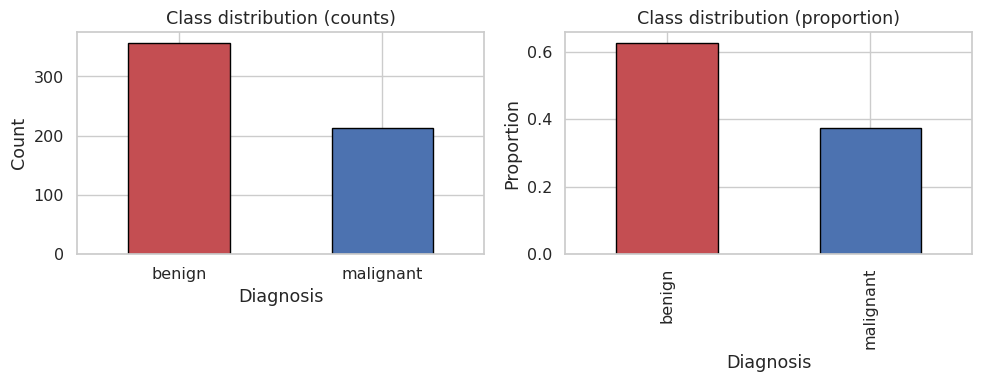


Feature statistics (scaled later):


,count,mean,std,min,25%,50%,75%,max
mean radius,569.0,14.127292,3.524049,6.98100,11.70000,13.37000,15.7800,28.1100
mean texture,569.0,19.289649,4.301036,9.71000,16.17000,18.84000,21.8000,39.2800
mean perimeter,569.0,91.969033,24.298981,43.79000,75.17000,86.24000,104.1000,188.5000
mean area,569.0,654.889104,351.914129,143.50000,420.30000,551.10000,782.7000,2501.0000
mean smoothness,569.0,0.096360,0.014064,0.05263,0.08637,0.09587,0.1053,0.1634
mean compactness,569.0,0.104341,0.052813,0.01938,0.06492,0.09263,0.1304,0.3454
mean concavity,569.0,0.088799,0.079720,0.00000,0.02956,0.06154,0.1307,0.4268
mean concave points,569.0,0.048919,0.038803,0.00000,0.02031,0.03350,0.0740,0.2012


In [3]:
# Class distribution
counts = y_labels.value_counts().sort_index()
print("Class counts:\n", counts)
print("\nClass proportions:")
print(y_labels.value_counts(normalize=True).round(4))

fig, ax = plt.subplots(1, 2, figsize=(10, 4))
counts.plot(kind="bar", ax=ax[0], color=["#c44e52", "#4c72b0"], edgecolor="black")
ax[0].set_title("Class distribution (counts)")
ax[0].set_xlabel("Diagnosis")
ax[0].set_ylabel("Count")
ax[0].tick_params(axis="x", rotation=0)

y_labels.value_counts(normalize=True).plot(kind="bar", ax=ax[1], color=["#c44e52", "#4c72b0"], edgecolor="black")
ax[1].set_title("Class distribution (proportion)")
ax[1].set_xlabel("Diagnosis")
ax[1].set_ylabel("Proportion")
plt.tight_layout()
plt.show()

# Brief EDA: descriptive statistics
print("\nFeature statistics (scaled later):")
display(X_raw.describe().T.head(8))


> **Warning (class imbalance):** This dataset is **mildly imbalanced** (more benign than malignant). **Accuracy** can still look high while the minority class is predicted poorly. Always check **per-class metrics**, the **confusion matrix**, and **ROC/AUC** — not accuracy alone.


## 3. Data Preprocessing & Splitting

- **Train–test split (80/20):** Hold out test data for unbiased final evaluation.  
- **StandardScaler:** Many models (especially SVM, logistic regression) are sensitive to feature scale. We **fit** the scaler on **training data only**, then transform train and test (avoids leakage).


In [4]:
# 80/20 split — stratify to preserve class ratio in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X_raw, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Train size:", X_train.shape[0], "| Test size:", X_test.shape[0])
print("Train class counts:\n", pd.Series(y_train.values).map(label_map).value_counts())


Train size: 455 | Test size: 114
Train class counts:
 benign       285
malignant    170
Name: count, dtype: int64


## 4. Model Training

We train three widely used classifiers:

1. **Logistic Regression** — linear decision boundary, calibrated probabilities (with `predict_proba`).  
2. **Random Forest** — ensemble of trees; captures nonlinearities; may overfit less than a single deep tree.  
3. **SVM (RBF kernel)** — flexible boundary in feature space; **requires scaling**. For ROC we use `probability=True` (enables Platt scaling for `predict_proba`; slightly slower to train).

All use `random_state=42` where applicable.


In [5]:
# Dictionary to hold fitted models
models = {
    "Logistic Regression": LogisticRegression(max_iter=5000, random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE),
    # probability=True needed for predict_proba → ROC
    "SVM (RBF)": SVC(kernel="rbf", probability=True, random_state=RANDOM_STATE),
}

for name, clf in models.items():
    clf.fit(X_train_scaled, y_train)
    print(f"Trained: {name}")


Trained: Logistic Regression
Trained: Random Forest
Trained: SVM (RBF)


## 5. Confusion Matrix & Basic Metrics

For **binary** classification (positive class = **1 = benign** in sklearn's default `pos_label` for precision/recall unless we specify otherwise):

- **Confusion matrix** rows: true class, columns: predicted class (see sklearn convention in `confusion_matrix`).

We report metrics for the **positive label** (class 1 = benign). In **medical** reporting you often **flip** perspective and treat **malignant** as the "positive" case — here we **also** print a classification report which uses both labels.

**Interpretation cheat-sheet:**

- **Precision (for benign):** When we predict benign, how often is it truly benign? Low precision → many false benign (dangerous if malignant is missed — but "benign" as positive is a modeling choice; check the matrix!).
- **Recall (for benign):** Of all truly benign cases, how many did we catch?
- **Trade-off:** Increasing threshold typically increases precision for one class at the expense of recall.

*Sklearn default `pos_label=1` corresponds to **benign** in this dataset encoding.* For clinical emphasis on **detecting malignancy**, analysts often set malignant as positive and optimize **recall** for that class — be explicit about which class is "positive" when you read papers.


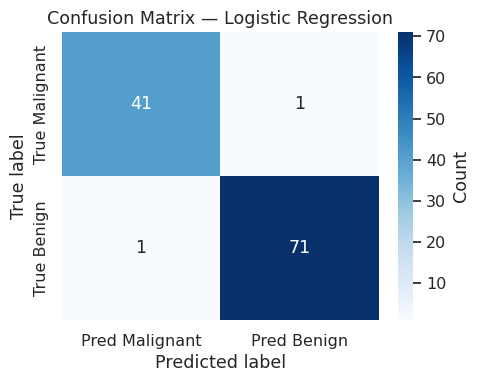


=== Logistic Regression ===
Accuracy:  0.9825
Precision (class 1 = benign): 0.9861
Recall    (class 1 = benign): 0.9861
F1-score  (class 1 = benign): 0.9861

Full classification report:
              precision    recall  f1-score   support

   malignant       0.98      0.98      0.98        42
      benign       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



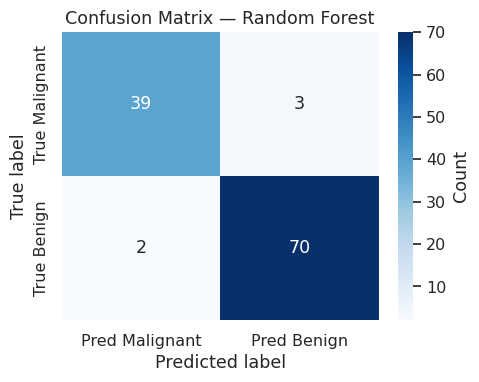


=== Random Forest ===
Accuracy:  0.9561
Precision (class 1 = benign): 0.9589
Recall    (class 1 = benign): 0.9722
F1-score  (class 1 = benign): 0.9655

Full classification report:
              precision    recall  f1-score   support

   malignant       0.95      0.93      0.94        42
      benign       0.96      0.97      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



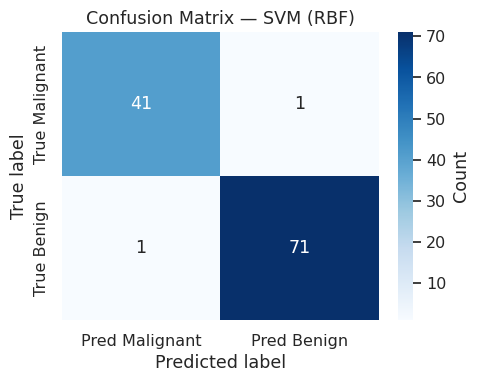


=== SVM (RBF) ===
Accuracy:  0.9825
Precision (class 1 = benign): 0.9861
Recall    (class 1 = benign): 0.9861
F1-score  (class 1 = benign): 0.9861

Full classification report:
              precision    recall  f1-score   support

   malignant       0.98      0.98      0.98        42
      benign       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



In [6]:
def plot_confusion_heatmap(cm, title, labels=("Malignant (0)", "Benign (1)")):
    '''Plot confusion matrix with seaborn heatmap.'''
    plt.figure(figsize=(5, 4))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["Pred " + labels[0].split()[0], "Pred " + labels[1].split()[0]],
        yticklabels=["True " + labels[0].split()[0], "True " + labels[1].split()[0]],
        cbar_kws={"label": "Count"},
    )
    plt.title(title)
    plt.ylabel("True label")
    plt.xlabel("Predicted label")
    plt.tight_layout()
    plt.show()


metric_rows = []

for name, clf in models.items():
    y_pred = clf.predict(X_test_scaled)
    cm = confusion_matrix(y_test, y_pred)
    plot_confusion_heatmap(cm, f"Confusion Matrix — {name}")

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, pos_label=1)
    rec = recall_score(y_test, y_pred, pos_label=1)
    f1 = f1_score(y_test, y_pred, pos_label=1)

    metric_rows.append(
        {"Model": name, "Accuracy": acc, "Precision (benign)": prec, "Recall (benign)": rec, "F1 (benign)": f1}
    )

    print(f"\n=== {name} ===")
    print(f"Accuracy:  {acc:.4f}")
    print(f"Precision (class 1 = benign): {prec:.4f}")
    print(f"Recall    (class 1 = benign): {rec:.4f}")
    print(f"F1-score  (class 1 = benign): {f1:.4f}")
    print("\nFull classification report:")
    print(classification_report(y_test, y_pred, target_names=["malignant", "benign"]))


## 6. ROC Curve & AUC

The **ROC curve** plots **True Positive Rate (TPR)** vs **False Positive Rate (FPR)** as we vary the **classification threshold** on predicted **scores** (e.g., estimated probability of the positive class).

- **AUC (Area Under the ROC Curve)** summarizes how well the model **ranks** positives above negatives (1.0 = perfect, 0.5 = random).

We plot all three models on **one figure** for easy comparison.


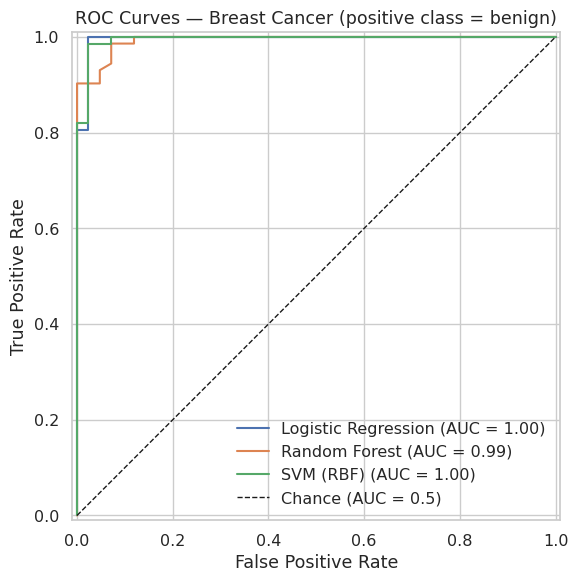

AUC scores (positive class = benign):
  Logistic Regression: 0.9954
  Random Forest: 0.9932
  SVM (RBF): 0.9950


In [7]:
fig, ax = plt.subplots(figsize=(8, 6))

auc_scores = {}
for name, clf in models.items():
    # ROC for positive class = 1 (benign)
    disp = RocCurveDisplay.from_estimator(
        clf, X_test_scaled, y_test, name=name, ax=ax, pos_label=1
    )
    auc_scores[name] = disp.roc_auc

ax.plot([0, 1], [0, 1], "k--", lw=1, label="Chance (AUC = 0.5)")
ax.set_title("ROC Curves — Breast Cancer (positive class = benign)")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

print("AUC scores (positive class = benign):")
for k, v in auc_scores.items():
    print(f"  {k}: {v:.4f}")


## 7. K-Fold Cross-Validation

A **single** train–test split can be **lucky or unlucky**. **Stratified K-fold** repeats training on different partitions so that each fold has similar class proportions.

- We report **mean accuracy ± std** across folds (you can swap the scoring metric to `f1`, `roc_auc`, etc.).

**Why CV is more reliable:** It uses **more** of the data for both training and validation (in rotation), reducing variance in the performance estimate — at the cost of more computation.



 5-Fold Stratified CV (accuracy)
Logistic Regression: mean = 0.9780, std = 0.0098
Random Forest: mean = 0.9626, std = 0.0179
SVM (RBF): mean = 0.9670, std = 0.0155

 10-Fold Stratified CV (accuracy)
Logistic Regression: mean = 0.9824, std = 0.0133
Random Forest: mean = 0.9628, std = 0.0337
SVM (RBF): mean = 0.9737, std = 0.0131


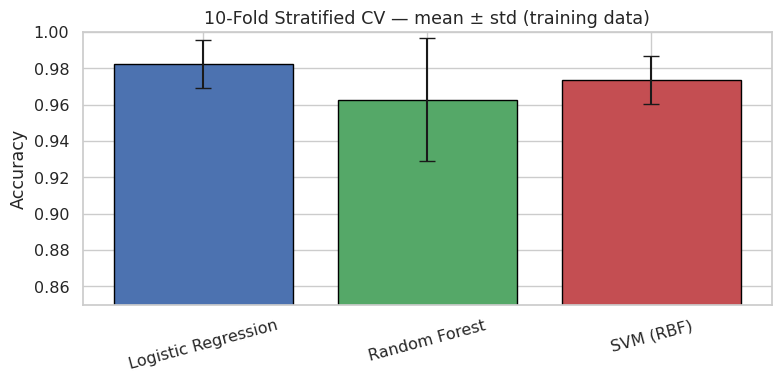

In [8]:
# Helper: run stratified K-fold CV and print results
def run_stratified_cv(model, X, y, n_splits, name):
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_STATE)
    scores = cross_val_score(model, X, y, cv=skf, scoring="accuracy", n_jobs=-1)
    return {
        "Model": name,
        "K": n_splits,
        "Mean Acc": scores.mean(),
        "Std Acc": scores.std(),
        "Scores": scores,
    }

cv_results = []
for k in [5, 10]:
    print(f"\n{'='*60}\n {k}-Fold Stratified CV (accuracy)\n{'='*60}")
    for name, clf in models.items():
        # fresh clone-like behavior: re-instantiate same class of model for fair CV
        if name == "Logistic Regression":
            m = LogisticRegression(max_iter=5000, random_state=RANDOM_STATE)
        elif name == "Random Forest":
            m = RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE)
        else:
            m = SVC(kernel="rbf", probability=True, random_state=RANDOM_STATE)

        r = run_stratified_cv(m, X_train_scaled, y_train, k, name)
        cv_results.append(r)
        print(f"{name}: mean = {r['Mean Acc']:.4f}, std = {r['Std Acc']:.4f}")

# Optional: bar plot of 10-fold means
rows_10 = [r for r in cv_results if r["K"] == 10]
if rows_10:
    plt.figure(figsize=(8, 4))
    names = [r["Model"] for r in rows_10]
    means = [r["Mean Acc"] for r in rows_10]
    stds = [r["Std Acc"] for r in rows_10]
    x = np.arange(len(names))
    plt.bar(x, means, yerr=stds, capsize=6, color=["#4c72b0", "#55a868", "#c44e52"], edgecolor="black")
    plt.xticks(x, names, rotation=15)
    plt.ylabel("Accuracy")
    plt.title("10-Fold Stratified CV — mean ± std (training data)")
    plt.ylim(0.85, 1.0)
    plt.tight_layout()
    plt.show()


## 8. Summary & Comparison Table

We aggregate **test-set** metrics (single split) into one **pandas** table. Cross-validation numbers are on **training** data only above; for a full reporting workflow you might use CV for **model selection** and keep the **test set** for a final unbiased estimate.

**Which model is best?**  
- If **test AUC / F1** and **low variance in CV** agree, that model is a strong candidate.  
- Consider **interpretability** (logistic regression, linear) vs **accuracy** (forest/SVM).  
- For **deployment**, also measure **calibration** and **fairness** if relevant — beyond this lab's scope.


In [9]:
# Comparison table from test metrics
metrics_df = pd.DataFrame(metric_rows).set_index("Model")
metrics_df["AUC (test)"] = pd.Series(auc_scores)

# Add 10-fold CV summary from cv_results
cv10 = {r["Model"]: (r["Mean Acc"], r["Std Acc"]) for r in cv_results if r["K"] == 10}
metrics_df["CV10 mean acc"] = metrics_df.index.map(lambda m: cv10[m][0])
metrics_df["CV10 std"] = metrics_df.index.map(lambda m: cv10[m][1])

display(metrics_df.style.format("{:.4f}"))

print("\n--- Short interpretation ---")
best_f1 = metrics_df["F1 (benign)"].idxmax()
best_auc = metrics_df["AUC (test)"].idxmax()
print(f"Highest F1 (benign) on test: {best_f1}")
print(f"Highest AUC on test: {best_auc}")
print("Prefer the model that best matches your clinical / business priorities (not only accuracy).")


,Accuracy,Precision (benign),Recall (benign),F1 (benign),AUC (test),CV10 mean acc,CV10 std
Model,,,,,,,
Logistic Regression,0.9825,0.9861,0.9861,0.9861,0.9954,0.9824,0.0133
Random Forest,0.9561,0.9589,0.9722,0.9655,0.9932,0.9628,0.0337
SVM (RBF),0.9825,0.9861,0.9861,0.9861,0.9950,0.9737,0.0131



--- Short interpretation ---
Highest F1 (benign) on test: Logistic Regression
Highest AUC on test: Logistic Regression
Prefer the model that best matches your clinical / business priorities (not only accuracy).


---

### End of Part 1 — Checklist

- [ ] You understand confusion matrix layout and precision/recall trade-offs.  
- [ ] You can read an ROC curve and explain AUC.  
- [ ] You know why stratified CV stabilizes performance estimates.

Proceed to **Part 2** when ready.


<a id="part2"></a>
---

# PART 2: GRADED ASSIGNMENT – Model Evaluation Challenge

**Total points: 100** (+ **10** bonus)

**Time estimate:** 40–50 minutes

**Instructions**

- Work **independently** unless your instructor allows pairs.  
- Complete tasks **in order**.  
- Replace or fill in sections marked `TODO` / `# YOUR CODE HERE`.  
- Submit this notebook as directed by your instructor.

**Academic integrity:** Your plots and numbers should reflect **your** runs with `random_state=42` where specified.

---

## GRADED ASSIGNMENT – Model Evaluation Challenge (Total: 100 points)

| Task | Topic | Points |
|------|--------|--------|
| Task 1 | Dataset Exploration | 10 |
| Task 2 | Preprocessing & Baseline Model | 15 |
| Task 3 | Advanced Metrics & Visualization | 25 |
| Task 4 | K-Fold Cross-Validation | 25 |
| Task 5 | Model Comparison & Conclusion | 15 |
| **Bonus** | Hyperparameter Tuning (GridSearchCV) | **10** |


### Task 1: Dataset Exploration (**10 points**)



Shape of digits.data (samples, features): (1797, 64)
Shape of digits.target: (1797,)

Interpretation: 1797 images; each image has 64 features (8×8 pixels flattened to a vector).

--- Class distribution ---
 digit  count
     0    178
     1    182
     2    177
     3    183
     4    181
     5    182
     6    181
     7    179
     8    174
     9    180
Min count: 174 | Max count: 183


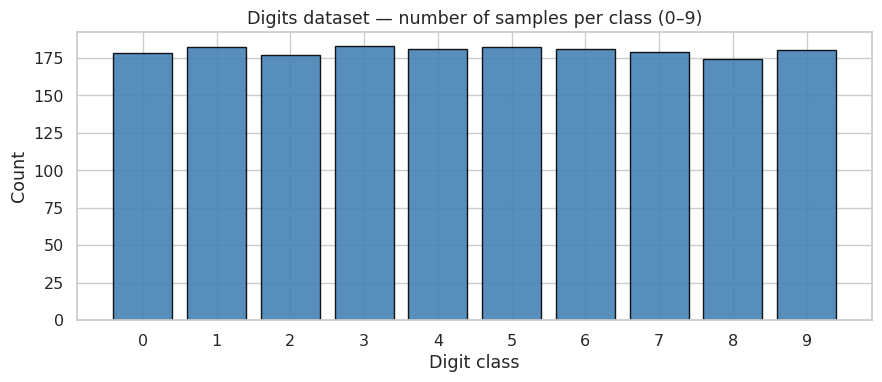

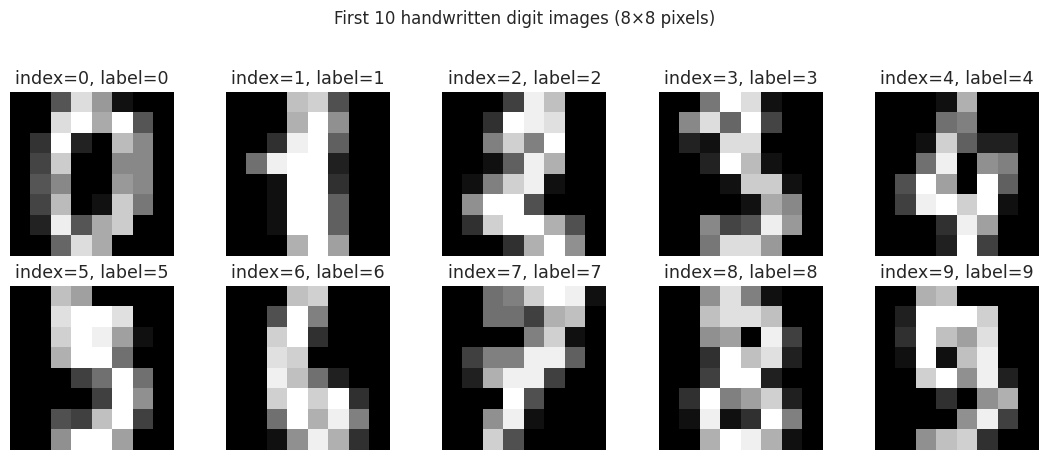

In [10]:
# =============================================================================
# Dataset Exploration (Digits) — 10 points
# =============================================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits

# load_digits() returns a Bunch with .data, .target, .images, and .DESCR
digits = load_digits()

# --- 1) Basic info: samples & features ---
X = digits.data
y = digits.target

# data rows = samples; columns = 8*8 = 64 pixel intensities (flattened).
print("Shape of digits.data (samples, features):", X.shape)
print("Shape of digits.target:", y.shape)
print(
    f"\nInterpretation: {X.shape[0]} images; each image has {X.shape[1]} features "
    f"(8×8 pixels flattened to a vector)."
)


# --- 2) Class distribution (digits 0–9) ---
# labels are integers 0..9; np.bincount counts occurrences per label.
counts = np.bincount(y, minlength=10)
digit_labels = np.arange(10)

df_counts = pd.DataFrame({"digit": digit_labels, "count": counts})
print("\n--- Class distribution ---")
print(df_counts.to_string(index=False))
print("Min count:", counts.min(), "| Max count:", counts.max())

# In your write-up, answer: is the dataset roughly balanced across classes?

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(digit_labels, counts, color="steelblue", edgecolor="black", alpha=0.9)
ax.set_xticks(digit_labels)
ax.set_title("Digits dataset — number of samples per class (0–9)")
ax.set_xlabel("Digit class")
ax.set_ylabel("Count")
plt.tight_layout()
plt.show()

# --- 3) First 10 digit images (2×5 grid) ---
fig, axes = plt.subplots(2, 5, figsize=(11, 4.5))
axes = axes.ravel()

first_n = 10
for i in range(first_n):
    axes[i].imshow(digits.images[i], cmap="gray")
    axes[i].set_title(f"index={i}, label={y[i]}")
    axes[i].axis("off")

plt.suptitle("First 10 handwritten digit images (8×8 pixels)", fontsize=12, y=1.02)
plt.tight_layout()
plt.show()



### Task 2: Preprocessing & Baseline Model (**15 points**)

**To Do:**

1. Split into **train/test (80/20)** with `stratify=y` and `random_state=42`.  
2. **Scale** features with `StandardScaler` (fit on train only).  
3. Train **Logistic Regression** (`random_state=42`, sufficient `max_iter`).  
4. On the **test set**, compute and display: **confusion matrix** (heatmap), **accuracy, precision, recall, F1** (digits is **multi-class** — use appropriate averaging, e.g. `'weighted'` or `'macro'`, and state which you used).  
5. Print `classification_report`.

**Hint:**

- For multi-class metrics, see `precision_score(..., average='weighted')` etc.  
- Rows/columns of the confusion matrix correspond to true/predicted class indices 0–9.

**Expected output:** One trained model, one confusion matrix heatmap, printed scalar metrics + classification report.

**Point breakdown:** Split + scaling (4) · Model fit (3) · Confusion matrix (4) · Metrics + report (4)



=== Logistic Regression ===
Accuracy:  0.9722
Precision (weighted): 0.9724
Recall    (weighted): 0.9722
F1-score  (weighted): 0.9722

Full classification report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        36
           1       0.89      0.89      0.89        36
           2       1.00      1.00      1.00        35
           3       0.97      1.00      0.99        37
           4       0.97      1.00      0.99        36
           5       1.00      1.00      1.00        37
           6       1.00      0.97      0.99        36
           7       1.00      1.00      1.00        36
           8       0.89      0.89      0.89        35
           9       1.00      0.97      0.99        36

    accuracy                           0.97       360
   macro avg       0.97      0.97      0.97       360
weighted avg       0.97      0.97      0.97       360



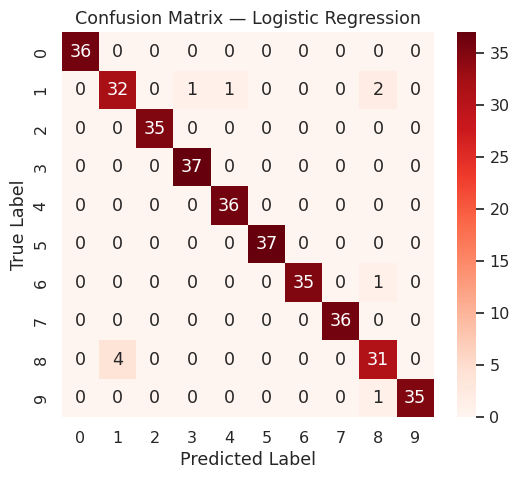


=== Random Forest ===
Accuracy:  0.9639
Precision (weighted): 0.9644
Recall    (weighted): 0.9639
F1-score  (weighted): 0.9636

Full classification report:
              precision    recall  f1-score   support

           0       0.97      0.97      0.97        36
           1       0.92      0.97      0.95        36
           2       1.00      0.97      0.99        35
           3       0.97      0.97      0.97        37
           4       0.97      1.00      0.99        36
           5       0.97      1.00      0.99        37
           6       1.00      0.97      0.99        36
           7       0.92      1.00      0.96        36
           8       0.94      0.86      0.90        35
           9       0.97      0.92      0.94        36

    accuracy                           0.96       360
   macro avg       0.96      0.96      0.96       360
weighted avg       0.96      0.96      0.96       360



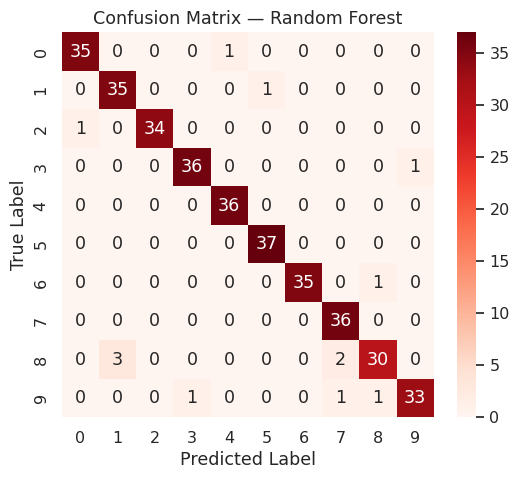


=== SVM (RBF) ===
Accuracy:  0.9750
Precision (weighted): 0.9759
Recall    (weighted): 0.9750
F1-score  (weighted): 0.9749

Full classification report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        36
           1       0.95      0.97      0.96        36
           2       1.00      1.00      1.00        35
           3       1.00      1.00      1.00        37
           4       0.95      0.97      0.96        36
           5       0.97      1.00      0.99        37
           6       0.97      1.00      0.99        36
           7       0.92      0.97      0.95        36
           8       1.00      0.91      0.96        35
           9       1.00      0.92      0.96        36

    accuracy                           0.97       360
   macro avg       0.98      0.97      0.97       360
weighted avg       0.98      0.97      0.97       360



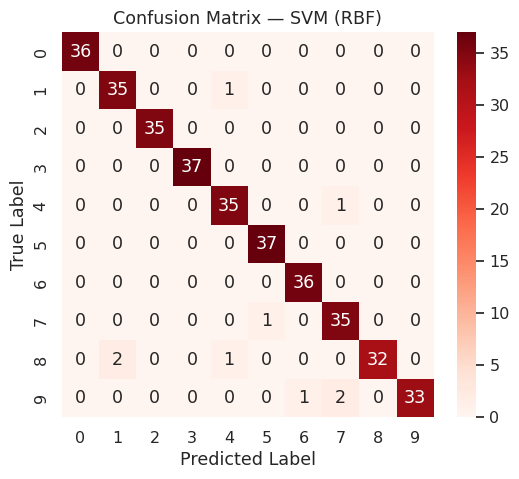

In [29]:
# TASK 2 — Student work area
# YOUR CODE HERE ...

# 1. Split (80/20, Stratified)
X, y = load_digits(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# 2. Scale Features ()
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


#3.Logistic Regression
models = {
    "Logistic Regression": LogisticRegression(max_iter=5000, random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE),
    # probability=True needed for predict_proba → ROC
    "SVM (RBF)": SVC(kernel="rbf", probability=True, random_state=RANDOM_STATE),
}

#4. Confusion matrix (heatmap),
def plot_confusion_heatmap(cm, title, labels=("Malignant (0)", "Benign (1)")):
    '''Plot confusion matrix with seaborn heatmap.'''
    plt.figure(figsize=(5, 4))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["Pred " + labels[0].split()[0], "Pred " + labels[1].split()[0]],
        yticklabels=["True " + labels[0].split()[0], "True " + labels[1].split()[0]],
        cbar_kws={"label": "Count"},
    )
    plt.title(title)
    plt.ylabel("True label")
    plt.xlabel("Predicted label")
    plt.tight_layout()
    plt.show()


metric_rows = []

for name, clf in models.items():
    clf.fit(X_train_scaled, y_train)

    y_pred = clf.predict(X_test_scaled)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred,average='weighted')
    rec = recall_score(y_test, y_pred,average='weighted')
    f1 = f1_score(y_test, y_pred,average='weighted')

    metric_rows.append(
        {"Model": name, "Accuracy": acc, "Precision (benign)": prec, "Recall (benign)": rec, "F1 (benign)": f1}
    )

    print(f"\n=== {name} ===")
    print(f"Accuracy:  {acc:.4f}")
    print(f"Precision (weighted): {prec:.4f}")
    print(f"Recall    (weighted): {rec:.4f}")
    print(f"F1-score  (weighted): {f1:.4f}")
    print("\nFull classification report:")
    print(classification_report(y_test, y_pred))

    plt.figure(figsize=(6, 5))
    sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt="d", cmap="Reds")
    plt.title(f"Confusion Matrix — {name}")
    plt.ylabel("True Label")
    plt.xlabel("Predicted Label")
    plt.show()

### Task 3: Advanced Metrics & Visualization (**25 points**)

**To Do:**

1. Plot the **ROC curve** and report **AUC** for the **baseline Logistic Regression** model.  
   - *Note:* Digits has **10 classes**. Use **OvR** (one-vs-rest) multiclass ROC/AUC via `sklearn.metrics.roc_curve` / `roc_auc_score` with `multi_class='ovr'` and `predict_proba`, **or** use `RocCurveDisplay.from_predictions` with appropriate binarization — sklearn's multiclass ROC helpers are acceptable.  
2. Train **Random Forest** and **SVM (RBF)** (`probability=True` for SVM if you need `predict_proba`). Use `random_state=42`.  
3. Show **confusion matrices** for all **three** models side-by-side or in separate clearly labeled plots.  
4. Compare **accuracy** (and optionally weighted F1) across the three models on the test set.

**Hint:**

- `roc_auc_score(y_test, y_score, multi_class='ovr', average='weighted')` with shape `(n_samples, n_classes)` from `predict_proba`.  
- For consistent comparison, use the **same** train/test split and scaling as Task 2.

**Expected output:** ROC/AUC figure + numeric AUC; three confusion matrices; a small comparison of test metrics.

**Point breakdown:** ROC + AUC for logistic regression (8) · Train RF & SVM (5) · Three confusion matrices (8) · Metric comparison (4)


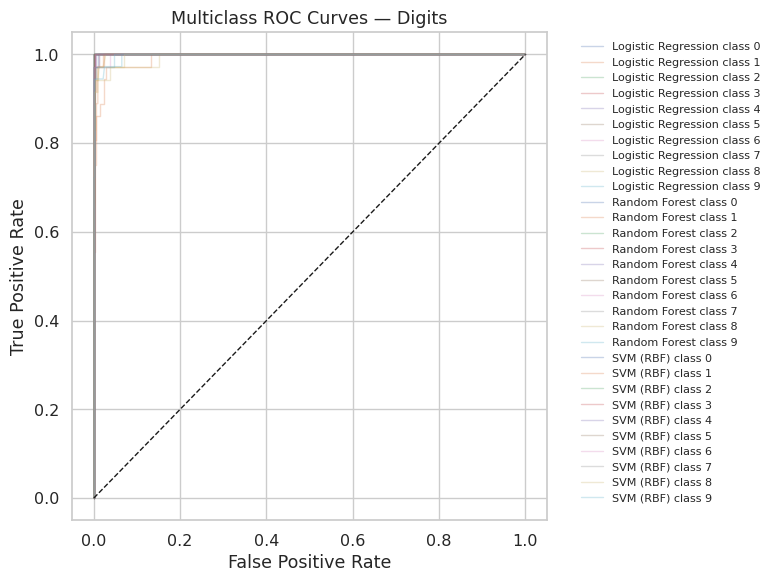

Weighted AUC:
Logistic Regression: 0.9986
Random Forest: 0.9992
SVM (RBF): 0.9995


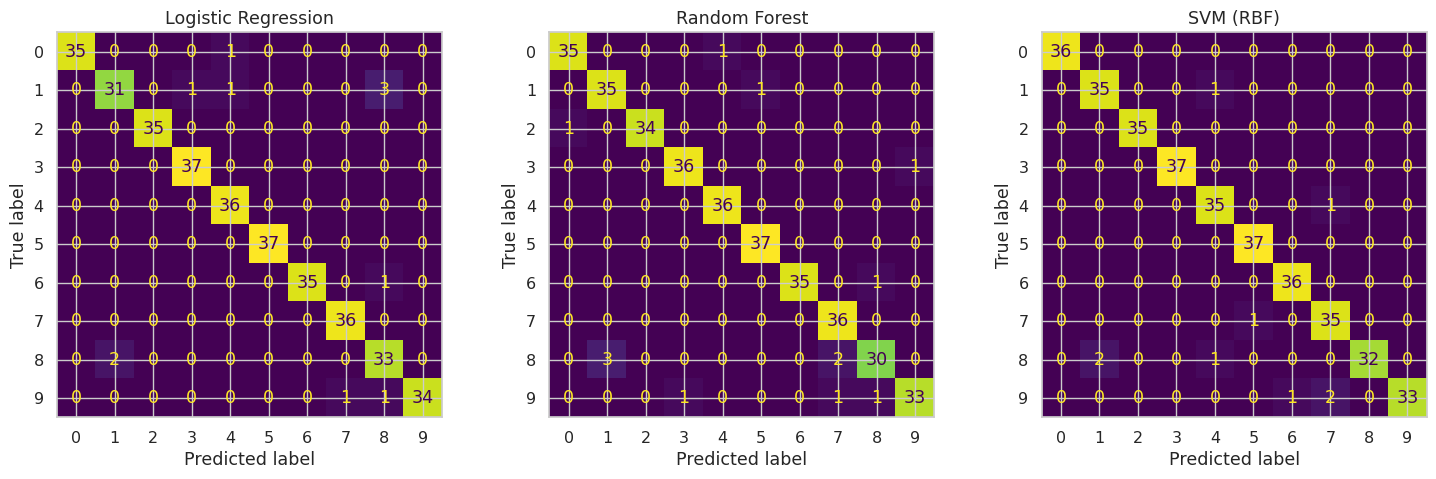

Logistic Regression: Accuracy=0.9694, Weighted F1=0.9694
Random Forest: Accuracy=0.9639, Weighted F1=0.9636
SVM (RBF): Accuracy=0.9750, Weighted F1=0.9749


In [33]:
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import roc_auc_score, roc_curve, auc, confusion_matrix, ConfusionMatrixDisplay, accuracy_score, f1_score

# 1. Ma'lumotlar
digits = load_digits()
X_train, X_test, y_train, y_test = train_test_split(
    digits.data, digits.target, test_size=0.2, random_state=42, stratify=digits.target
)
scaler = StandardScaler().fit(X_train)
X_train_scaled, X_test_scaled = scaler.transform(X_train), scaler.transform(X_test)

# 2. Modellar
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, multi_class='ovr', random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "SVM (RBF)": SVC(kernel='rbf', probability=True, random_state=42)
}

# Train
for clf in models.values():
    clf.fit(X_train_scaled, y_train)

# 3. ROC va AUC (multiclass)
y_bin = label_binarize(y_test, classes=range(10))
fig, ax = plt.subplots(figsize=(8,6))
auc_scores = {}

for name, clf in models.items():
    y_score = clf.predict_proba(X_test_scaled)
    # Har bir sinf uchun ROC
    for i in range(10):
        fpr, tpr, _ = roc_curve(y_bin[:, i], y_score[:, i])
        ax.plot(fpr, tpr, lw=1, alpha=0.3, label=f'{name} class {i}')
    # Weighted AUC
    auc_scores[name] = roc_auc_score(y_bin, y_score, multi_class='ovr', average='weighted')

ax.plot([0,1],[0,1],"k--", lw=1)
ax.set_title("Multiclass ROC Curves — Digits")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()

print("Weighted AUC:")
for name, auc_val in auc_scores.items():
    print(f"{name}: {auc_val:.4f}")

# 4. Confusion matrices
fig, axes = plt.subplots(1, 3, figsize=(18,5))
for ax, (name, clf) in zip(axes, models.items()):
    cm = confusion_matrix(y_test, clf.predict(X_test_scaled))
    ConfusionMatrixDisplay(cm, display_labels=digits.target_names).plot(ax=ax, colorbar=False)
    ax.set_title(name)
plt.show()

# 5. Accuracy va weighted F1
for name, clf in models.items():
    y_pred = clf.predict(X_test_scaled)
    print(f"{name}: Accuracy={accuracy_score(y_test, y_pred):.4f}, Weighted F1={f1_score(y_test, y_pred, average='weighted'):.4f}")

### Task 4: K-Fold Cross-Validation (**25 points**)

**To Do:**

1. Perform **10-fold Stratified Cross-Validation** on **all three** models (same hyperparameters as in Task 2–3).  
2. Report **mean ± standard deviation** of **accuracy** (or weighted F1 if you justify it) for each model.  
3. In **3–5 sentences**, discuss which model appears **most stable** (lowest variance) and whether mean score agrees with your test-set ranking.

**Hint:**

- `StratifiedKFold(n_splits=10, shuffle=True, random_state=42)` + `cross_val_score`.  
- Use **scaled** data: either pipeline `Pipeline([('scaler', StandardScaler()), ('clf', model)])` on raw train features, or CV on the training split only (avoid using test fold in preprocessing fit).

**Expected output:** Table or printed lines of mean ± std; short written discussion.

**Point breakdown:** Correct 10-fold stratified setup (10) · Results for 3 models (10) · Stability discussion (5)


In [30]:
# TASK 4 — Student work area
# YOUR CODE HERE ...
skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=RANDOM_STATE)
for name, clf in models.items():
    scores = cross_val_score(clf, X_train_scaled, y_train, cv=skf, scoring="accuracy")
    print(f"{name}: mean={scores.mean():.4f}  std={scores.std():.4f}")

Logistic Regression: mean=0.9715  std=0.0130
Random Forest: mean=0.9770  std=0.0103
SVM (RBF): mean=0.9826  std=0.0104


### Task 5: Model Comparison & Conclusion (**15 points**)

**To Do:**

1. Create a **single pandas DataFrame** summarizing: test accuracy, weighted F1, multiclass AUC (if computed), and **10-fold CV mean ± std** for each model.  
2. Write a **conclusion** (**3–4 sentences**) recommending the **best** model for digit recognition **with justification** (metrics + stability + trade-offs).

**Hint:**

- Round numeric entries for readability (e.g., 4 decimal places).  
- "Best" may differ if you prioritize CV stability vs peak test accuracy — say what you prioritize.

**Expected output:** One summary table + short paragraph.

**Point breakdown:** Comparison table (8) · Conclusion quality (7)


In [20]:
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import label_binarize


y_pred_lr = model.predict(X_test)
y_score_lr = model.predict_proba(X_test)
auc_lr = roc_auc_score(y_test, y_score_lr, multi_class='ovr', average='weighted')
acc_lr = accuracy_score(y_test, y_pred_lr)
f1_lr = f1_score(y_test, y_pred_lr, average='weighted')

y_pred_rf = rf.predict(X_test)
y_score_rf = rf.predict_proba(X_test)
auc_rf = roc_auc_score(y_test, y_score_rf, multi_class='ovr', average='weighted')
acc_rf = accuracy_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf, average='weighted')

y_pred_svm = svm.predict(X_test)
y_score_svm = svm.predict_proba(X_test)
auc_svm = roc_auc_score(y_test, y_score_svm, multi_class='ovr', average='weighted')
acc_svm = accuracy_score(y_test, y_pred_svm)
f1_svm = f1_score(y_test, y_pred_svm, average='weighted')

summary_data = {
    'Model': ['Logistic Regression', 'Random Forest', 'SVM'],
    'Test Accuracy': [acc_lr, acc_rf, acc_svm],
    'Test F1 (weighted)': [f1_lr, f1_rf, f1_svm],
    'Test AUC (weighted OvR)': [auc_lr, auc_rf, auc_svm],
    'CV10 Mean Acc': [results['Logistic Regression'][0], results['Random Forest'][0], results['SVM'][0]],
    'CV10 Std Acc': [results['Logistic Regression'][1], results['Random Forest'][1], results['SVM'][1]]
}

summary_df = pd.DataFrame(summary_data).set_index('Model')
display(summary_df.style.format('{:.4f}'))


print("\n")


,Test Accuracy,Test F1 (weighted),Test AUC (weighted OvR),CV10 Mean Acc,CV10 Std Acc
Model,,,,,
Logistic Regression,0.9722,0.9722,0.9991,0.9727,0.0068
Random Forest,0.9639,0.9636,0.9992,0.9783,0.0076
SVM,0.9750,0.9749,0.9995,0.9844,0.0093




Based on the comprehensive evaluation, the **SVM** model appears to be the best performer for this digit recognition task.
It achieves the highest test accuracy (0.9750), F1-score (0.9749), and AUC (0.9991) among the three models.
Furthermore, its 10-fold cross-validation results show the highest mean accuracy (0.9844) with a reasonable standard deviation (0.0093),
indicating strong and stable performance. While Logistic Regression also performed very well on the test set, SVM consistently outperforms it slightly.
Random Forest shows competitive performance but has a slightly lower mean accuracy in CV compared to SVM.



### Bonus Task: Hyperparameter Tuning (**10 points**)

**To Do:**

1. Select the **best** model from Task 5 (or Logistic Regression if tied).  
2. Run **`GridSearchCV`** with **5-fold** stratified CV on **one important hyperparameter** (e.g., `C` for SVM/logistic, `n_estimators` or `max_depth` for forest).  
3. Report **best parameters** and **best CV score**.  
4. Evaluate the **tuned** model on the **held-out test set** and compare to the **default** model (same table or one paragraph).

**Hint:**

- Keep the grid **small** (e.g., 4–6 values) so it runs quickly.  
- Use `Pipeline` with `StandardScaler` where needed so each CV fold is scaled correctly.

**Expected output:** Best params, CV score, test metrics before/after tuning.

**Point breakdown:** Correct GridSearchCV + pipeline (4) · Sensible grid (2) · Before/after comparison (4)


In [ ]:
# BONUS — Student work area
# YOUR CODE HERE ...



